# SGD Classifier: Stochastic Gradient Descent pro klasifikaci

## Co je SGD Classifier?

SGD (Stochastic Gradient Descent) Classifier je lineární klasifikační model, který se učí pomocí stochastického gradientního sestupu. Je zvláště užitečný pro velké datové sady a online učení, kde se data postupně přidávají.

### Kdy použít SGD Classifier:
- Pro velké datové sady (miliony vzorků)
- Když potřebujete online učení
- Pro lineárně oddělitelné problémy
- Když je efektivita paměti důležitá

### Výhody:
- Efektivní pro velké datové sady
- Nízké paměťové nároky (nepotřebuje celou datovou sadu v paměti)
- Podporuje online učení a částečné dávkové učení
- Podporuje různé ztrátové funkce a regularizace

### Nevýhody:
- Vyžaduje pečlivé nastavení hyperparametrů (zejména learning rate)
- Citlivý na změnu měřítka příznaků
- Pro malé datové sady mohou jiné algoritmy poskytovat lepší výkon

Pojďme nyní implementovat SGD Classifier na reálném datasetu.

In [1]:
# Import potřebných knihoven
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# Nastavení pro reprodukovatelnost výsledků
np.random.seed(42)

# Nastavení pro lepší vizualizaci
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Načtení a příprava dat

Použijeme dataset MNIST, který obsahuje obrázky ručně psaných číslic (0-9). Je to klasický dataset pro demonstraci klasifikačních algoritmů.

In [2]:
# # Načtení MNIST datasetu
# print("Načítání MNIST datasetu...")
# mnist = fetch_openml('mnist_784', version=1)
# print("Dataset načten.")

# # Extrahujeme features a target
# X = mnist.data.astype('float64')
# y = mnist.target.astype('int')

# # Pro rychlejší zpracování použijeme pouze subset dat
# # Pro plný dataset odstraňte následující řádky
# subset_size = 10000
# indices = np.random.choice(X.shape[0], subset_size, replace=False)
# X = X[indices]
# y = y[indices]

# # Rozdělení na trénovací a testovací sadu
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# print(f"Tvar trénovacích dat: {X_train.shape}")
# print(f"Tvar testovacích dat: {X_test.shape}")

```
KeyError: "None of [Index([46730, 48393, 41416, 34506, 43725, 11615, 24656, 22411,   936, 56364,\n       ...\n       21724, 26506, 54406, 52508, 59459, 20679, 48140, 59195, 12633, 39641],\n      dtype='int32', length=10000)] are in the [columns]"
```

In [3]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np

# Načtení MNIST datasetu
print("Načítání MNIST datasetu...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
print("Dataset načten.")

# Extrahujeme features a target
X = mnist.data.astype('float64')
y = mnist.target.astype('int')

# Pro rychlejší zpracování použijeme pouze subset dat
subset_size = 10000
indices = np.random.choice(X.shape[0], subset_size, replace=False)
X = X[indices]  # numpy array → funguje správně
y = y[indices]

# Rozdělení na trénovací a testovací sadu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tvar trénovacích dat: {X_train.shape}")
print(f"Tvar testovacích dat: {X_test.shape}")

Načítání MNIST datasetu...
Dataset načten.
Tvar trénovacích dat: (8000, 784)
Tvar testovacích dat: (2000, 784)


### Vizualizace několika obrázků z datasetu

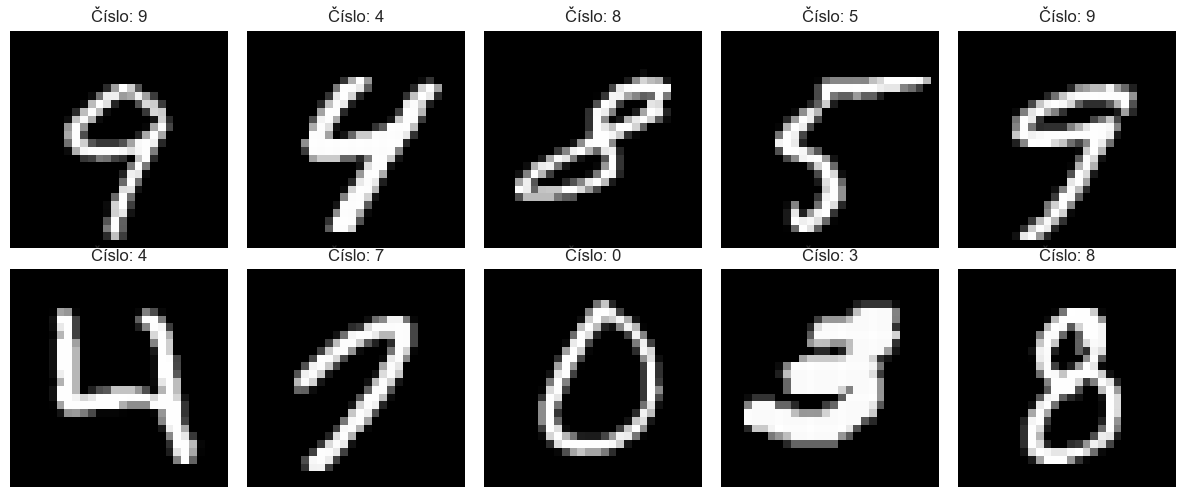

In [4]:
# Zobrazíme několik obrázků z datasetu
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    # Reshapujeme data zpět do tvaru obrázku (28x28 pixelů)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Číslo: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Implementace SGD Classifier

SGD Classifier potřebuje standardizovaná data, protože je citlivý na měřítko příznaků. Vytvoříme pipeline, který bude obsahovat standardizaci a SGD Classifier.

In [5]:
# # Vytvoření pipeline se standardizací a SGD klasifikátorem
# sgd_clf = make_pipeline(
#     StandardScaler(),
#     SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
# )

# # Trénování modelu
# print("Trénování SGD klasifikátoru...")
# sgd_clf.fit(X_train, y_train)
# print("Model natrénován.")

# # Predikce na testovacích datech
# y_pred = sgd_clf.predict(X_test)

# # Vyhodnocení přesnosti
# accuracy = accuracy_score(y_test, y_pred)
# print(f"Přesnost modelu: {accuracy:.4f}")

```
ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
```

In [6]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

# Vytvoření pipeline se standardizací a SGD klasifikátorem
sgd_clf = make_pipeline(
    StandardScaler(),
    SGDClassifier(max_iter=3000, tol=1e-4, random_state=42, early_stopping=True, n_iter_no_change=5)
)

# Trénování modelu
print("Trénování SGD klasifikátoru...")
sgd_clf.fit(X_train, y_train)
print("Model natrénován.")

# Predikce na testovacích datech
y_pred = sgd_clf.predict(X_test)

# Vyhodnocení přesnosti
accuracy = accuracy_score(y_test, y_pred)
print(f"Přesnost modelu: {accuracy:.4f}")

Trénování SGD klasifikátoru...
Model natrénován.
Přesnost modelu: 0.8900


## 3. Podrobné vyhodnocení modelu

Klasifikační report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       180
           1       0.93      0.96      0.95       232
           2       0.89      0.86      0.87       181
           3       0.88      0.85      0.86       229
           4       0.87      0.91      0.89       178
           5       0.86      0.86      0.86       185
           6       0.94      0.95      0.94       194
           7       0.88      0.92      0.90       225
           8       0.85      0.74      0.79       178
           9       0.88      0.87      0.87       218

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



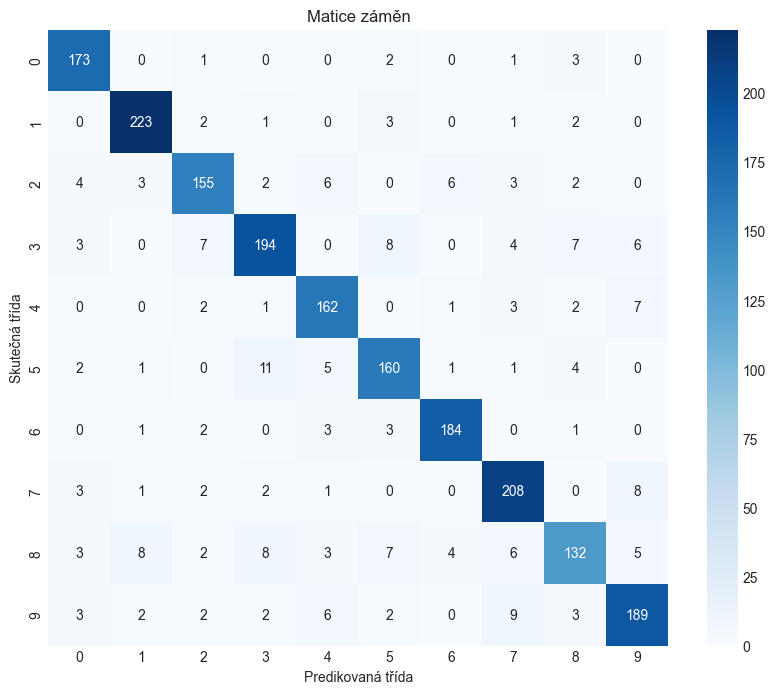

In [7]:
# Tisk klasifikačního reportu
print("Klasifikační report:")
print(classification_report(y_test, y_pred))

# Matice záměn
cm = confusion_matrix(y_test, y_pred)

# Vizualizace matice záměn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predikovaná třída')
plt.ylabel('Skutečná třída')
plt.title('Matice záměn')
plt.show()

## 4. Křížová validace pro robustnější vyhodnocení

In [8]:
# Křížová validace pro vyhodnocení robustnosti modelu
print("Provádění křížové validace...")
cv_scores = cross_val_score(sgd_clf, X_train, y_train, cv=5)
print(f"Skóre křížové validace: {cv_scores}")
print(f"Průměrné skóre křížové validace: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

Provádění křížové validace...
Skóre křížové validace: [0.8925   0.888125 0.881875 0.895625 0.89375 ]
Průměrné skóre křížové validace: 0.8904 (±0.0049)


## 5. Ladění hyperparametrů

SGD Classifier má několik důležitých hyperparametrů, které můžeme optimalizovat pro zlepšení výkonu.

In [9]:
# Definice parametrů pro GridSearchCV
param_grid = {
    'sgdclassifier__alpha': [0.0001, 0.001, 0.01],
    'sgdclassifier__loss': ['hinge', 'log_loss', 'modified_huber'],
    'sgdclassifier__penalty': ['l2', 'l1', 'elasticnet']
}

# Vytvoření GridSearchCV
grid_search = GridSearchCV(sgd_clf, param_grid, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)

# Pro urychlení použijeme menší subset dat
grid_sample_size = 5000
grid_indices = np.random.choice(X_train.shape[0], grid_sample_size, replace=False)
X_grid_sample = X_train[grid_indices]
y_grid_sample = y_train[grid_indices]

# Spuštění vyhledávání nejlepších parametrů
print("Hledání nejlepších hyperparametrů...")
grid_search.fit(X_grid_sample, y_grid_sample)
print("Hledání dokončeno.")

# Výsledky grid search
print(f"Nejlepší skóre: {grid_search.best_score_:.4f}")
print(f"Nejlepší parametry: {grid_search.best_params_}")

Hledání nejlepších hyperparametrů...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Hledání dokončeno.
Nejlepší skóre: 0.8896
Nejlepší parametry: {'sgdclassifier__alpha': 0.001, 'sgdclassifier__loss': 'log_loss', 'sgdclassifier__penalty': 'elasticnet'}


## 6. Trénování optimalizovaného modelu

S optimálními parametry nyní natrénujeme finální model.

In [10]:
# # Vytvoření optimalizovaného SGD klasifikátoru s nejlepšími parametry
# best_loss = grid_search.best_params_['sgdclassifier__loss']
# best_alpha = grid_search.best_params_['sgdclassifier__alpha']
# best_penalty = grid_search.best_params_['sgdclassifier__penalty']

# optimized_sgd_clf = make_pipeline(
#     StandardScaler(), 
#     SGDClassifier(
#         loss=best_loss,
#         alpha=best_alpha,
#         penalty=best_penalty,
#         max_iter=1000,
#         tol=1e-3,
#         random_state=42
#     )
# )

# # Trénování optimalizovaného modelu
# print("Trénování optimalizovaného modelu...")
# optimized_sgd_clf.fit(X_train, y_train)
# print("Optimalizovaný model natrénován.")

# # Vyhodnocení optimalizovaného modelu
# y_opt_pred = optimized_sgd_clf.predict(X_test)
# opt_accuracy = accuracy_score(y_test, y_opt_pred)
# print(f"Přesnost optimalizovaného modelu: {opt_accuracy:.4f}")
# print("\nKlasifikační report optimalizovaného modelu:")
# print(classification_report(y_test, y_opt_pred))

```
ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
```

In [11]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

# Vytvoření optimalizovaného SGD klasifikátoru s nejlepšími parametry
best_loss = grid_search.best_params_['sgdclassifier__loss']
best_alpha = grid_search.best_params_['sgdclassifier__alpha']
best_penalty = grid_search.best_params_['sgdclassifier__penalty']

optimized_sgd_clf = make_pipeline(
    StandardScaler(), 
    SGDClassifier(
        loss=best_loss,
        alpha=best_alpha,
        penalty=best_penalty,
        max_iter=3000,           # zvýšeno z 1000
        tol=1e-4,                # zpřesněno
        early_stopping=True,     # přidáno pro stabilní trénink
        n_iter_no_change=5,      # zastaví pokud se nezlepšuje
        validation_fraction=0.1, # default (10 % trénovacích dat pro validaci)
        random_state=42
    )
)

# Trénování optimalizovaného modelu
print("Trénování optimalizovaného modelu...")
optimized_sgd_clf.fit(X_train, y_train)
print("Optimalizovaný model natrénován.")

# Vyhodnocení optimalizovaného modelu
y_opt_pred = optimized_sgd_clf.predict(X_test)
opt_accuracy = accuracy_score(y_test, y_opt_pred)
print(f"Přesnost optimalizovaného modelu: {opt_accuracy:.4f}")
print("\nKlasifikační report optimalizovaného modelu:")
print(classification_report(y_test, y_opt_pred))

Trénování optimalizovaného modelu...
Optimalizovaný model natrénován.
Přesnost optimalizovaného modelu: 0.8930

Klasifikační report optimalizovaného modelu:
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       180
           1       0.93      0.95      0.94       232
           2       0.87      0.88      0.88       181
           3       0.90      0.83      0.86       229
           4       0.89      0.91      0.90       178
           5       0.87      0.86      0.87       185
           6       0.94      0.94      0.94       194
           7       0.90      0.92      0.91       225
           8       0.83      0.78      0.81       178
           9       0.86      0.88      0.87       218

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



## 7. Křivka učení (Learning Curve)

Křivka učení je užitečný nástroj pro analýzu chování modelu v závislosti na velikosti trénovací sady.

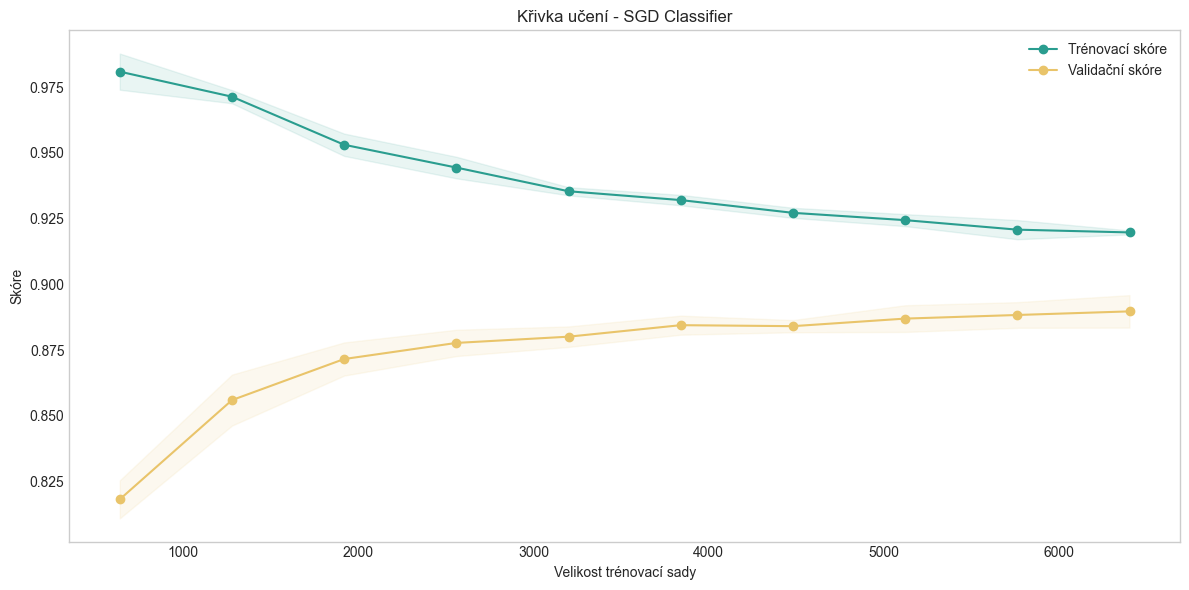

In [12]:
# Generování křivky učení
train_sizes, train_scores, validation_scores = learning_curve(
    optimized_sgd_clf, X_train, y_train, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='accuracy', n_jobs=-1
)

# Výpočet průměru a směrodatné odchylky
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)
validation_scores_std = np.std(validation_scores, axis=1)

# Vizualizace křivky učení
plt.figure(figsize=(12, 6))
plt.title('Křivka učení - SGD Classifier')
plt.xlabel('Velikost trénovací sady')
plt.ylabel('Skóre')
plt.grid()

# Vykreslení průměrných trénovacích a validačních skóre
plt.plot(train_sizes, train_scores_mean, 'o-', color='#2A9D8F', label='Trénovací skóre')
plt.plot(train_sizes, validation_scores_mean, 'o-', color='#E9C46A', label='Validační skóre')

# Vykreslení intervalů spolehlivosti
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color='#2A9D8F')
plt.fill_between(train_sizes, validation_scores_mean - validation_scores_std,
                 validation_scores_mean + validation_scores_std, alpha=0.1, color='#E9C46A')

# Zobrazení legendy a grafu
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## 8. Vizualizace predikcí

Podíváme se na některé příklady správných a nesprávných predikcí našeho modelu.

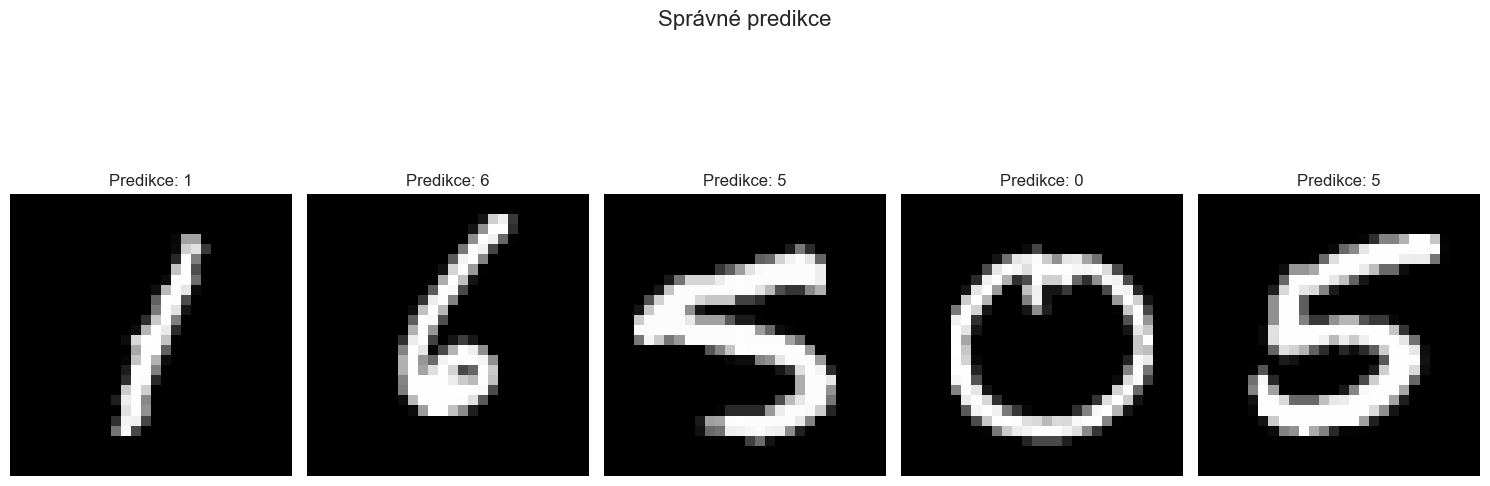

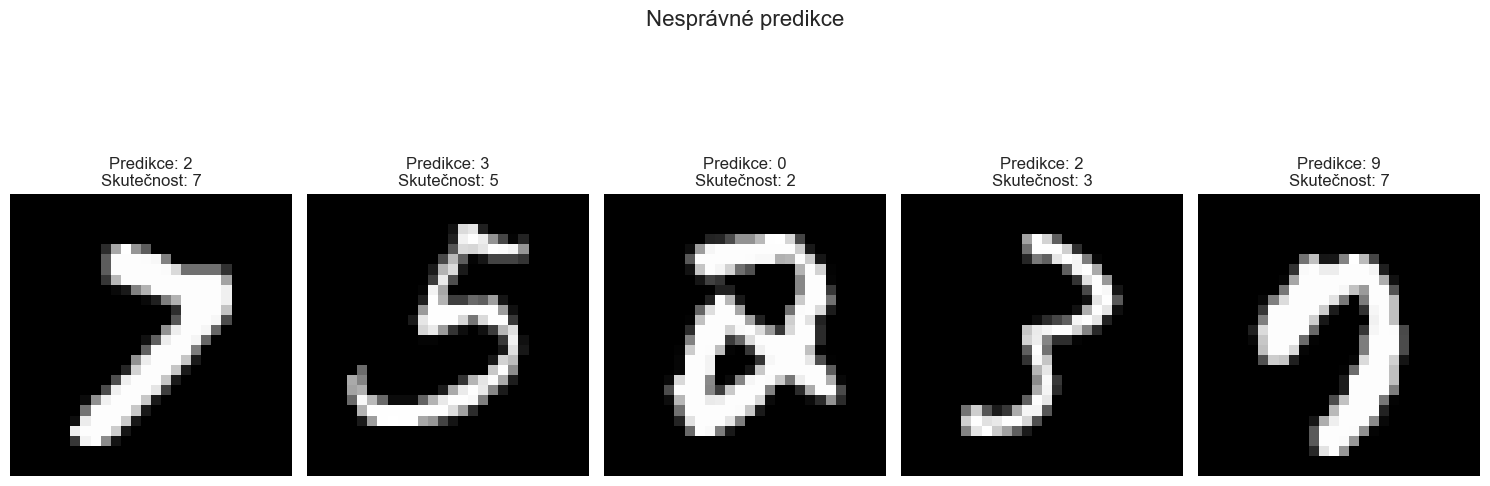

In [13]:
# Získání indexů správných a nesprávných predikcí
correct = np.where(y_opt_pred == y_test)[0]
incorrect = np.where(y_opt_pred != y_test)[0]

# Zobrazení správných predikcí
plt.figure(figsize=(15, 6))
plt.suptitle('Správné predikce', fontsize=16)
for i, idx in enumerate(np.random.choice(correct, 5, replace=False)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Predikce: {y_opt_pred[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

# Zobrazení nesprávných predikcí
if len(incorrect) > 0:
    plt.figure(figsize=(15, 6))
    plt.suptitle('Nesprávné predikce', fontsize=16)
    for i, idx in enumerate(np.random.choice(incorrect, min(5, len(incorrect)), replace=False)):
        plt.subplot(1, 5, i + 1)
        plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
        plt.title(f"Predikce: {y_opt_pred[idx]}\nSkutečnost: {y_test[idx]}")
        plt.axis('off')
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()
else:
    print("Nebyly nalezeny žádné nesprávné predikce!")

## 9. Incidence vzorků v průběhu učení (online učení)

Jednou z hlavních výhod SGD Classifier je jeho schopnost online učení. Demonstrujeme, jak přidávat nové vzorky postupně.

In [14]:
# # Vytvoření SGD klasifikátoru pro online učení
# online_sgd = make_pipeline(
#     StandardScaler(with_mean=False),  # Poznámka: pro online učení nemůžeme použít with_mean=True
#     SGDClassifier(max_iter=1, warm_start=True, random_state=42)
# )

# # Rozdělení trénovacích dat do dávek
# batch_size = len(X_train) // 10
# n_batches = 10

# train_accuracies = []
# test_accuracies = []

# # Online učení s postupným přidáváním dávek
# for i in range(n_batches):
#     # Výběr aktuální dávky
#     batch_start = i * batch_size
#     batch_end = (i + 1) * batch_size
#     X_batch = X_train[batch_start:batch_end]
#     y_batch = y_train[batch_start:batch_end]
    
#     # Částečné učení na aktuální dávce
#     online_sgd.fit(X_batch, y_batch)
    
#     # Vyhodnocení na aktuální dávce a testovacích datech
#     train_acc = online_sgd.score(X_batch, y_batch)
#     test_acc = online_sgd.score(X_test, y_test)
    
#     train_accuracies.append(train_acc)
#     test_accuracies.append(test_acc)
    
#     print(f"Dávka {i+1}/{n_batches}: Trénovací přesnost = {train_acc:.4f}, Testovací přesnost = {test_acc:.4f}")

# # Vizualizace procesu učení
# plt.figure(figsize=(12, 6))
# plt.plot(range(1, n_batches + 1), train_accuracies, 'o-', label='Trénovací přesnost', color='#2A9D8F')
# plt.plot(range(1, n_batches + 1), test_accuracies, 'o-', label='Testovací přesnost', color='#E9C46A')
# plt.xlabel('Počet zpracovaných dávek')
# plt.ylabel('Přesnost')
# plt.title('Online učení SGD klasifikátoru')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

```
ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
```

Dávka 1/10: Trénovací přesnost = 0.9187, Testovací přesnost = 0.8085
Dávka 2/10: Trénovací přesnost = 0.8650, Testovací přesnost = 0.7800
Dávka 3/10: Trénovací přesnost = 0.8888, Testovací přesnost = 0.8300
Dávka 4/10: Trénovací přesnost = 0.8988, Testovací přesnost = 0.8185
Dávka 5/10: Trénovací přesnost = 0.8725, Testovací přesnost = 0.8200
Dávka 6/10: Trénovací přesnost = 0.8825, Testovací přesnost = 0.8080
Dávka 7/10: Trénovací přesnost = 0.8650, Testovací přesnost = 0.8140
Dávka 8/10: Trénovací přesnost = 0.9287, Testovací přesnost = 0.8525
Dávka 9/10: Trénovací přesnost = 0.9038, Testovací přesnost = 0.8455
Dávka 10/10: Trénovací přesnost = 0.9187, Testovací přesnost = 0.8440


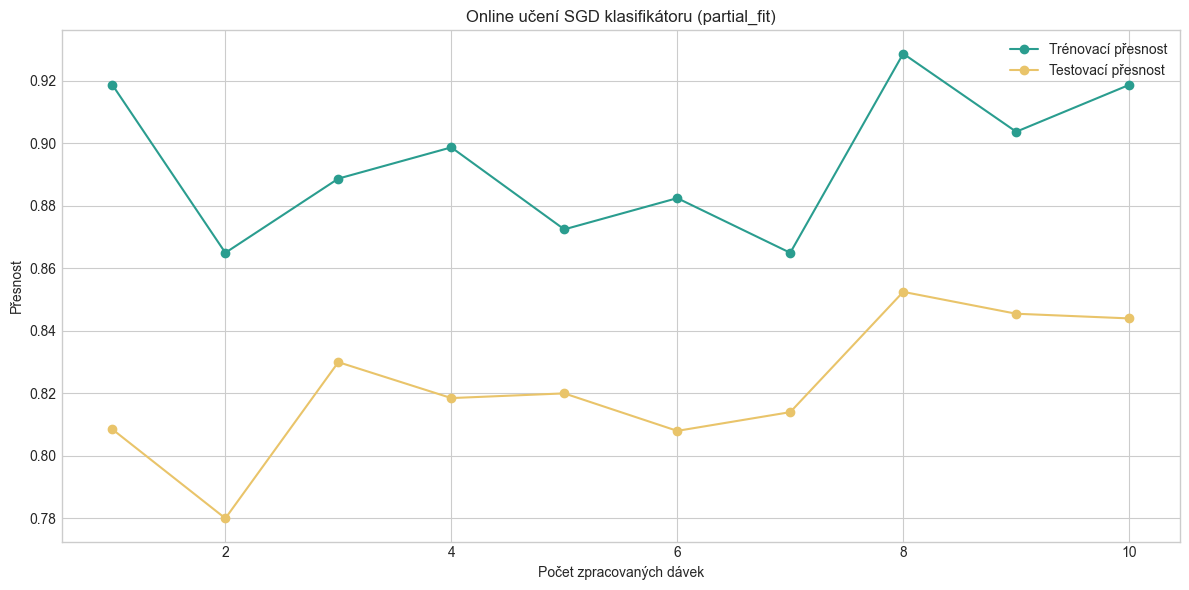

In [15]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Vytvoření SGD klasifikátoru pro online učení
# Note: StandardScaler musí být fitnutý předem pro partial_fit
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Inicializace SGD klasifikátoru
online_clf = SGDClassifier(random_state=42)

# Rozdělení trénovacích dat do dávek
batch_size = len(X_train_scaled) // 10
n_batches = 10

train_accuracies = []
test_accuracies = []

# Online učení s postupným přidáváním dávek
for i in range(n_batches):
    batch_start = i * batch_size
    batch_end = (i + 1) * batch_size
    X_batch = X_train_scaled[batch_start:batch_end]
    y_batch = y_train[batch_start:batch_end]
    
    # Částečné učení
    if i == 0:
        # První dávka musí předat seznam všech tříd
        online_clf.partial_fit(X_batch, y_batch, classes=np.unique(y_train))
    else:
        online_clf.partial_fit(X_batch, y_batch)

    # Vyhodnocení
    train_acc = online_clf.score(X_batch, y_batch)
    test_acc = online_clf.score(X_test_scaled, y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Dávka {i+1}/{n_batches}: Trénovací přesnost = {train_acc:.4f}, Testovací přesnost = {test_acc:.4f}")

# Vizualizace procesu učení
plt.figure(figsize=(12, 6))
plt.plot(range(1, n_batches + 1), train_accuracies, 'o-', label='Trénovací přesnost', color='#2A9D8F')
plt.plot(range(1, n_batches + 1), test_accuracies, 'o-', label='Testovací přesnost', color='#E9C46A')
plt.xlabel('Počet zpracovaných dávek')
plt.ylabel('Přesnost')
plt.title('Online učení SGD klasifikátoru (partial_fit)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 10. Srovnání s jinou implementací lineární klasifikace

Srovnáme SGD Classifier s klasickým logistickým regresorem, abychom ukázali rozdíly.

Srovnání SGD Classifier vs. Logistic Regression:

SGD Classifier: Čas trénování = 29.308s, Přesnost = 0.8895
Logistic Regression: Čas trénování = 1.140s, Přesnost = 0.8810


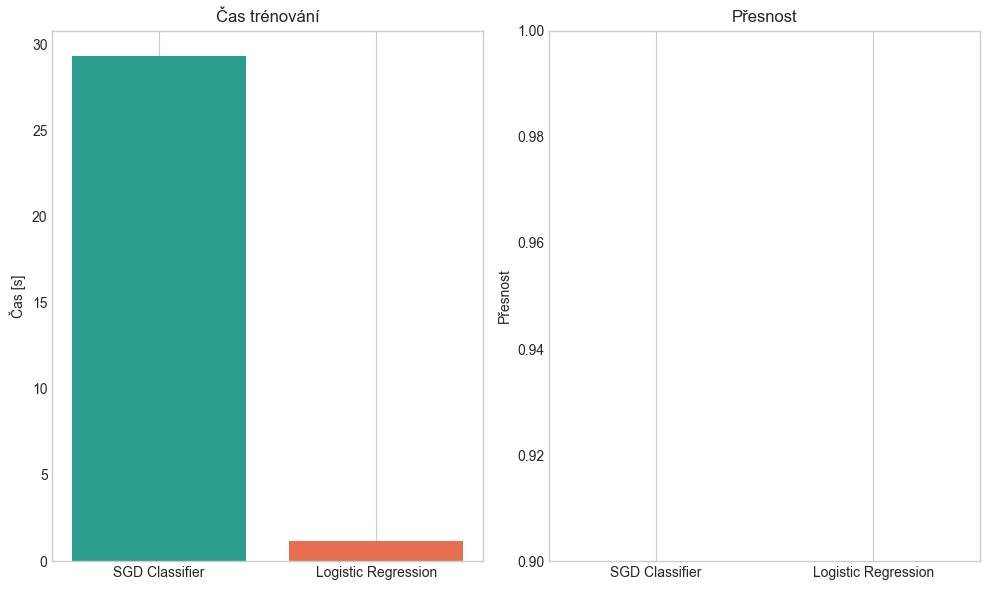

In [16]:
from sklearn.linear_model import LogisticRegression
from time import time

# Porovnání rychlosti a výkonu s LogisticRegression
# Pro spravedlivé srovnání použijeme menší subset dat
compare_size = 5000
compare_indices = np.random.choice(X_train.shape[0], compare_size, replace=False)
X_compare = X_train[compare_indices]
y_compare = y_train[compare_indices]

# SGD Classifier
sgd_pipeline = make_pipeline(StandardScaler(), 
                           SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, random_state=42))

# Logistic Regression
lr_pipeline = make_pipeline(StandardScaler(), 
                          LogisticRegression(max_iter=1000, random_state=42))

# Měření času trénování pro SGD Classifier
start_time = time()
sgd_pipeline.fit(X_compare, y_compare)
sgd_train_time = time() - start_time
sgd_accuracy = sgd_pipeline.score(X_test, y_test)

# Měření času trénování pro Logistic Regression
start_time = time()
lr_pipeline.fit(X_compare, y_compare)
lr_train_time = time() - start_time
lr_accuracy = lr_pipeline.score(X_test, y_test)

# Výsledky srovnání
print("Srovnání SGD Classifier vs. Logistic Regression:\n")
print(f"SGD Classifier: Čas trénování = {sgd_train_time:.3f}s, Přesnost = {sgd_accuracy:.4f}")
print(f"Logistic Regression: Čas trénování = {lr_train_time:.3f}s, Přesnost = {lr_accuracy:.4f}")

# Vizualizace srovnání
plt.figure(figsize=(10, 6))
models = ['SGD Classifier', 'Logistic Regression']
train_times = [sgd_train_time, lr_train_time]
accuracies = [sgd_accuracy, lr_accuracy]

# Subplot pro čas trénování
plt.subplot(1, 2, 1)
plt.bar(models, train_times, color=['#2A9D8F', '#E76F51'])
plt.title('Čas trénování')
plt.ylabel('Čas [s]')
plt.grid(axis='y')

# Subplot pro přesnost
plt.subplot(1, 2, 2)
plt.bar(models, accuracies, color=['#2A9D8F', '#E76F51'])
plt.title('Přesnost')
plt.ylabel('Přesnost')
plt.grid(axis='y')
plt.ylim(0.9, 1.0)  # Lepší škálování pro vizualizaci rozdílu v přesnosti

plt.tight_layout()
plt.show()

## 11. Závěr

### Shrnutí

V tomto notebooku jsme demonstrovali použití SGD Classifier pro klasifikaci ručně psaných číslic. 

**Klíčové poznatky:**

1. **Efektivita** - SGD Classifier je vysoce efektivní pro velké datové sady díky svému přístupu stochastického gradientního sestupu.

2. **Standardizace** - Algoritmus je citlivý na měřítko příznaků, proto je standardizace dat kritická pro dobrý výkon.

3. **Hyperparametry** - Klíčové hyperparametry jako alpha (regularizační parametr), loss (ztrátová funkce) a penalty (typ regularizace) významně ovlivňují výkon modelu.

4. **Online učení** - SGD Classifier podporuje online učení, kde může model průběžně aktualizovat své parametry s novými daty.

5. **Srovnání** - Pro menší datové sady mohou jiné algoritmy (např. Logistic Regression) poskytovat srovnatelný nebo lepší výkon, ale pro velké datasety je SGD Classifier často efektivnější z hlediska času a paměti.

### Doporučení pro použití SGD Classifier v praxi:

1. Vždy standardizujte vstupní příznaky.
2. Experimentujte s různými ztrátovými funkcemi podle povahy problému.
3. Použijte cross-validaci pro správné nastavení hyperparametrů.
4. Pro velké datové sady zvažte využití částečného dávkového zpracování.
5. Sledujte proces konvergence - pokud model nekonverguje, zvyšte max_iter nebo upravte learning_rate.